## Graph
graph三要素：state（状态）、node（节点）、edge（边）

### State

#### 1.1 TypedDict定义state (推荐)

k1: logs, v: []
k1: cur_id, v: 
k1: time, v: 0
k2: logs, v: ['node_1运行完毕']
k2: cur_id, v: node_1
k2: time, v: 12
k3: logs, v: ['node_1运行完毕']
k3: cur_id, v: node_1
k3: time, v: 12
k4: logs, v: ['node_1运行完毕', 'node_2运行完毕', 'node_3运行完毕']
k4: cur_id, v: node3
k4: time, v: 13
{'logs': ['node_1运行完毕', 'node_2运行完毕', 'node_3运行完毕', 'node_4运行完毕'], 'cur_id': 'node4', 'time': 111}


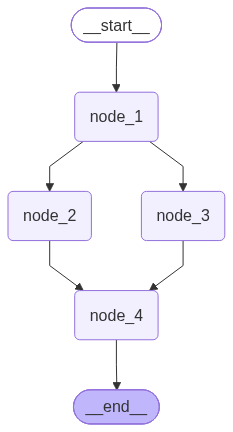

In [17]:
from time import sleep
# 定义 state 状态
from typing import TypedDict, Annotated
from operator import add
from IPython.display import display
from langgraph.types import Overwrite

def custom_reducer(left, right):
    return right

class OverallState(TypedDict): # 本质上为 dict
    logs: Annotated[list[str], add] # 日志类型为 list[str], 更新方式为 add (Annotated第二个参数为reducer)
    cur_id: Annotated[str, custom_reducer]
    time: Annotated[str, custom_reducer]

# 定义 node 执行节点
def node_1(state: OverallState) -> OverallState:
    for k, v in state.items():
        print(f"k1: {k}, v: {v}")

    return {
        "logs": ["node_1运行完毕"],
        "cur_id": "node_1",
        "time": 12
    }

def node_2(state: OverallState) -> OverallState:
    for k, v in state.items():
        print(f"k2: {k}, v: {v}")

    pre_time = state["time"]

    return {
        "logs": ["node_2运行完毕"],
        "cur_id": "node2",
        "time": pre_time + 1
    }

def node_3(state: OverallState) -> OverallState:
    for k, v in state.items():
        print(f"k3: {k}, v: {v}")

    pre_time = state["time"]

    return {
        "logs": ["node_3运行完毕"],
        "cur_id": "node3",
        "time": pre_time + 1
    }

def node_4(state: OverallState) -> OverallState:
    for k, v in state.items():
        print(f"k4: {k}, v: {v}")


    return {
        "logs": ["node_4运行完毕"],
        "cur_id": "node4",
        "time": Overwrite(111)
    }

# 定义 edge 流转边
from langgraph.graph import StateGraph, START, END

# 创建图
builder = StateGraph(state_schema=OverallState)

# 添加节点
builder.add_node(node_1)
builder.add_node(node_2)
builder.add_node(node_3)
builder.add_node(node_4)

# 添加边
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_3", "node_4")
builder.add_edge("node_2", "node_4")
builder.add_edge("node_4", END)

# 获取图
graph = builder.compile()

# 执行图
result = graph.invoke({ # 传入初始状态
    "logs": [],
    "cur_id": "",
    "time": 0
})

print(result)

# 可视化
display(graph)


#### 1.2 dataclass定义state

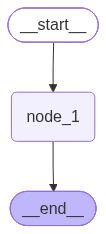

In [4]:
from dataclasses import dataclass
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from IPython.display import display

@dataclass
class OverallState: # 本质上为 class
    logs: Annotated[list[str], add]
    cur_id: str

def node_1(state: OverallState) -> OverallState:
    pre_id = state.cur_id
    # return OverallState(
    #     logs=state.logs + ["node_1运行完毕"],
    #     cur_id=pre_id + ", node_1"
    # )
    return {
        "logs": ["node_1运行完毕"],
        "cur_id": pre_id + ", node_1"
    }


builder = StateGraph(state_schema=OverallState)

builder.add_node(node_1)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

graph = builder.compile()

# 执行图
result = graph.invoke(OverallState(logs=[], cur_id=""))

display(graph)

#### 1.3 Pydantic定义state

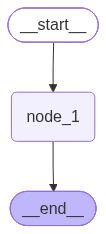

In [5]:
from pydantic import BaseModel
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from IPython.display import display

class OverallState(BaseModel): # 本质上为 class
    logs: Annotated[list[str], add]
    cur_id: str

def node_1(state: OverallState) -> OverallState:
    pre_id = state.cur_id
    # return OverallState(
    #     logs=state.logs + ["node_1运行完毕"],
    #     cur_id=pre_id + ", node_1"
    # )
    return {
        "logs": ["node_1运行完毕"],
        "cur_id": pre_id + ", node_1"
    }

builder = StateGraph(state_schema=OverallState)

builder.add_node(node_1)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

graph = builder.compile()

# 执行图
result = graph.invoke(OverallState(logs=[], cur_id=""))

display(graph)

#### 1.4 reducer (规约函数)<br>
用于不同节点，同一状态键的值进行合并

In [2]:
from langchain.messages import SystemMessage, AIMessage, HumanMessage
from langgraph.graph.message import add_messages # 根据id来进行新增/替换
from rich import print as rprint

left = [
    SystemMessage(content="你是一个话少的助手", id="1"),
    HumanMessage(content="你好", id="2"),
    AIMessage(content="早上好呀，有什么我能帮助你的", id="3")
]

right = [HumanMessage(content="我想问你一些关于LangGraph的知识", id="4")]

result = add_messages(left, right)

rprint(result)

[
    SystemMessage(content='你是一个话少的助手', additional_kwargs={}, response_metadata={}, id='1'),
    HumanMessage(content='你好', additional_kwargs={}, response_metadata={}, id='2'),
    AIMessage(
        content='早上好呀，有什么我能帮助你的',
        additional_kwargs={},
        response_metadata={},
        id='3',
        tool_calls=[],
        invalid_tool_calls=[]
    ),
    HumanMessage(content='我想问你一些关于LangGraph的知识', additional_kwargs={}, response_metadata={}, id='4')
]

#### 1.5 四种不同的state

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 输入状态
class InputState(TypedDict):
    username: str

# 输出状态
class OutputState(TypedDict):
    graph_output: str

# 全局状态
class OverAllState(TypedDict):
    username: str
    nickname: str
    graph_output: str

class PrivateState(TypedDict):
    greeting: str

#### 1.6 预定义state

In [11]:
# model
from rich import print as rprint
from dotenv import load_dotenv
load_dotenv(override=True)
from langchain.chat_models import init_chat_model
model = init_chat_model(
    model="deepseek-v4-flash", # 模型名称
    extra_body={
        "thinking": {"type": "disabled"}
}
)

In [16]:
# MessagesState
from langgraph.graph.message import MessagesState
from langchain.messages import SystemMessage, AIMessage, HumanMessage
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class OverAllState(MessagesState):
    user_name: str
    graph_output: str

class InputState(TypedDict):
    user_name: str

class OutputState(TypedDict):
    graph_output: str

def start_node(state: InputState) -> OverAllState:
    return {
        "messages": [
            SystemMessage(content="你是一个话少的助手"),
            HumanMessage(content=f"你好, 我是{state["user_name"]}")
        ]
    }

def llm_node(state: OverAllState) -> OverAllState:
    return {
        "messages": model.invoke(state["messages"]),
    }

def end_node(state: OverAllState) -> OutputState:
    return {
        "graph_output": state["messages"][-1].content
    }

builder = StateGraph(state_schema=OverAllState, input_schema=InputState, output_schema=OutputState)

builder.add_edge(START, "start_node")
builder.add_sequence([start_node, llm_node, end_node]) # add_sequence 简便写法，不需要手动添加 add_node
builder.add_edge("end_node", END)

graph = builder.compile()
result = graph.invoke({"user_name": "Reed"})
rprint(result)



{'graph_output': '你好，Reed。我是你的助手，有什么可以帮你的？'}